In [1]:
import time

import asyncio
import matplotlib.pyplot as plt
import nest_asyncio

from agents import Agent, Runner

nest_asyncio.apply()

In [2]:
# Agent focusing on product features
features_agent = Agent(
    name="FeaturesAgent",
    instructions="Extract the key product features from the review."
)

# Agent focusing on pros & cons
pros_cons_agent = Agent(
    name="ProsConsAgent",
    instructions="List the pros and cons mentioned in the review."
)

# Agent focusing on sentiment analysis
sentiment_agent = Agent(
    name="SentimentAgent",
    instructions="Summarize the overall user sentiment from the review."
)

# Agent focusing on recommendation summary
recommend_agent = Agent(
    name="RecommendAgent",
    instructions="State whether you would recommend this product and why."
)

parallel_agents = [
    features_agent,
    pros_cons_agent,
    sentiment_agent,
    recommend_agent
]

# Meta-agent to combine outputs
meta_agent = Agent(
    name="MetaAgent",
    instructions="You are given multiple summaries labeled with Features, ProsCons, Sentiment, and a Recommendation."
    " Combine them into a concise executive summary of the product review with a 1-5 star rating for each summary area."
)

In [3]:
starts, ends = [], []
async def run_agent(agent, review_text: str):
    agent_name = agent.name

    start = time.time()
    starts.append((agent_name, start))

    result = await Runner.run(agent, review_text)

    end = time.time()
    ends.append((agent_name, end))

    return result

In [4]:
async def run_agents(review_text: str):
    responses = await asyncio.gather(
        *(run_agent(agent, review_text) for agent in parallel_agents)
    )

    labeled_summaries = [
        f"### {resp.last_agent.name}\n{resp.final_output}"
        for resp in responses
    ]

    collected_summaries = "\n".join(labeled_summaries)
    final_summary = await run_agent(meta_agent, collected_summaries)


    print('Final summary:', final_summary.final_output)

    return

Final summary: ### Executive Summary
The AuroraSound X2 is a premium, comfortable pair of headphones with strong noise cancellation, clear balanced sound, excellent battery life, and fast, stable Bluetooth connectivity. The companion EQ app and transparency mode add useful flexibility. Downsides are mostly minor: a bulky case, occasional touch-control misfires, limited color options, and a somewhat high price.

**Overall rating:** ★★★★☆ (4/5)

### Summary Ratings
- **Design & Comfort:** ★★★★★
- **Sound Quality:** ★★★★☆
- **Noise Cancellation & Transparency:** ★★★★★
- **Connectivity & Controls:** ★★★★☆
- **Battery Life:** ★★★★★
- **Value:** ★★★☆☆

**Recommendation:** Yes, recommended—especially for users prioritizing ANC, comfort, and long battery life.


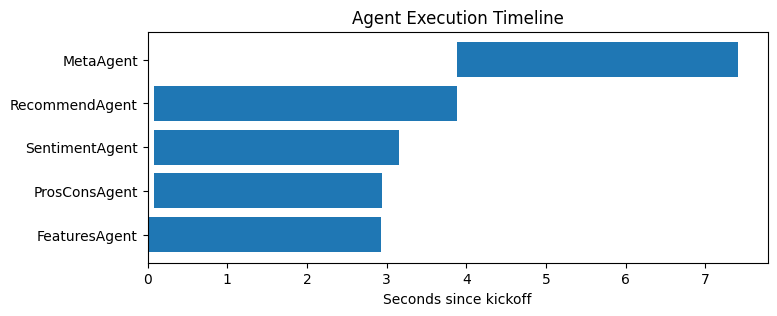

In [5]:
review_text = """
I recently upgraded to the AuroraSound X2 wireless noise-cancelling headphones, and after two weeks of daily use I have quite a bit to share. First off, the design feels premium without being flashy: the matte‐finish ear cups are softly padded and rotate smoothly for storage, while the headband’s memory‐foam cushion barely presses on my temples even after marathon work calls. Connectivity is seamless—pairing with my laptop and phone took under five seconds each time, and the Bluetooth 5.2 link held rock-solid through walls and down the hallway.

The noise-cancelling performance is genuinely impressive. In a busy café with music and chatter swirling around, flipping on ANC immediately quiets low-level ambient hums, and it even attenuates sudden noises—like the barista’s milk frother—without sounding distorted. The “Transparency” mode is equally well‐tuned: voices come through clearly, but the world outside isn’t overwhelmingly loud. Audio quality in standard mode is rich and balanced, with tight bass, clear mids, and a hint of sparkle in the highs. There’s also a dedicated EQ app, where you can toggle between “Podcast,” “Bass Boost,” and “Concert Hall” presets or craft your own curve.

On the control front, intuitive touch panels let you play/pause, skip tracks, and adjust volume with a simple swipe or tap. One neat trick: holding down on the right ear cup invokes your phone’s voice assistant. Battery life lives up to the hype, too—over 30 hours with ANC on, and the quick‐charge feature delivers 2 hours of playtime from just a 10-minute top-up.

That said, it isn’t perfect. For one, the carrying case is a bit bulky, so it doesn’t slip easily into a slim bag. And while the touch interface is mostly reliable, I occasionally trigger a pause when trying to adjust the cup position. The headphones also come in only two colorways—black or white—which feels limiting given the premium price point.
"""

await run_agents(review_text)

def plot_timeline(starts, ends):

    # Plot the timeline of the agents
    # normalize times to zero
    base = min(t for _, t in starts)
    labels = [n for n, _ in starts]
    start_offsets = [t - base for _, t in starts]
    lengths = [ends[i][1] - starts[i][1] for i in range(len(starts))]

    plt.figure(figsize=(8, 3))
    plt.barh(labels, lengths, left=start_offsets)
    plt.xlabel("Seconds since kickoff")
    plt.title("Agent Execution Timeline")
    plt.show()

plot_timeline(starts, ends)